In [117]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [119]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper
from model.anfis import ANFIS, SklearnAnfisWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR

In [120]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [121]:
from tests.uci_test import Cryotheraphy, Haberman, Heart, Glass, Segmentaition, Wine, Thyroid, Immunotherapy, Iris, BreastCancer, AdultIncome, BankMarketing, PimaDiabetes, CarEvaluation
from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke
from torch.utils.data import DataLoader


experiment = CarEvaluation(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
#regression

,Description,Value
0,Session id,199
1,Target,target
2,Target type,Multiclass
3,Original data shape,"(1728, 7)"
4,Transformed data shape,"(1728, 22)"
5,Transformed train set shape,"(1384, 22)"
6,Transformed test set shape,"(344, 22)"
7,Categorical features,6
8,Preprocess,True
9,Imputation type,iterative


False

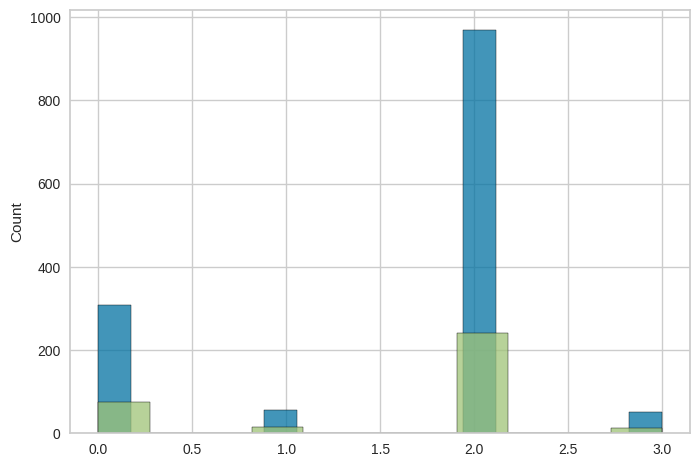

In [122]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [123]:
# prepare the model

from train.early_stop import EarlyStopping

model_params = {
    'type': "gift", # anfis, unfis, gift, litanfis
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 3,
    'drop_out_p': 0.3,
    'binary' : binary,  
    #'regression': regression,
    #'rank': 2,
    'zeta':1, # for GIFT
    #'eta':1  
}

model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs.squeeze(), batch_y.squeeze()) + cos(reconstructed, batch_X) * alpha 

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs, batch_y.long()) + cos(reconstructed, batch_X) * alpha 

In [124]:
# train

for epoch in range(epochs):
    
    model.train()
    train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs, reconstructed, entropy = model(batch_X)
        loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
        total_loss = loss
        total_loss.backward()
        optimizer.step()
        
        # Step the scheduler, but ignore the "exceeded total steps" error
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                # Reached the end of the scheduled steps; no further adjustments needed
                pass
            else:
                raise
    
    alpha *= alpha_decaying
    train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)
        
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output, _, _ = model(data)
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())

            val_loss += loss.item() * data.size(0)

    val_loss /= len(test_loader.dataset)

    print(
        f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    early_stopping(val_loss, model)
    # if early_stopping.early_stop:
    #     print("Early stopping")
    #     break
    
early_stopping.load_best_model(model)

Epoch 1, Train Loss: 0.0132, Val Loss: 1.3594
Epoch 2, Train Loss: 0.0073, Val Loss: 1.3289
Epoch 3, Train Loss: 0.0078, Val Loss: 1.2954
Epoch 4, Train Loss: 0.0074, Val Loss: 1.2552
Epoch 5, Train Loss: 0.0075, Val Loss: 1.2034
Epoch 6, Train Loss: 0.0060, Val Loss: 1.1396
Epoch 7, Train Loss: 0.0062, Val Loss: 1.0614
Epoch 8, Train Loss: 0.0057, Val Loss: 0.9733
Epoch 9, Train Loss: 0.0040, Val Loss: 0.8718
Epoch 10, Train Loss: 0.0039, Val Loss: 0.7679
Epoch 11, Train Loss: 0.0047, Val Loss: 0.6748
Epoch 12, Train Loss: 0.0061, Val Loss: 0.5983
Epoch 13, Train Loss: 0.0022, Val Loss: 0.5328
Epoch 14, Train Loss: 0.0029, Val Loss: 0.4871
Epoch 15, Train Loss: 0.0057, Val Loss: 0.4433
Epoch 16, Train Loss: 0.0034, Val Loss: 0.4057
Epoch 17, Train Loss: 0.0033, Val Loss: 0.3718
Epoch 18, Train Loss: 0.0035, Val Loss: 0.3539
Epoch 19, Train Loss: 0.0022, Val Loss: 0.3417
Epoch 20, Train Loss: 0.0030, Val Loss: 0.3317
Epoch 21, Train Loss: 0.0025, Val Loss: 0.3106
Epoch 22, Train Loss: 

In [125]:
%matplotlib inline  
experiment.evaluate_model(sk_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [126]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint 

if binary:
    train_auc = roc_auc_score(experiment.train_numpy()[1], sk_model.predict_proba(
        experiment.train_numpy()[0]))
    test_auc = roc_auc_score(experiment.test_numpy()[1], sk_model.predict_proba(
        experiment.test_numpy()[0]))
else:
    train_auc = roc_auc_score(experiment.train_numpy()[1], sk_model.predict_proba(
        experiment.train_numpy()[0]), multi_class='ovr')
    test_auc = roc_auc_score(experiment.test_numpy()[1], sk_model.predict_proba(
        experiment.test_numpy()[0]), multi_class='ovr')
result = ""

result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(experiment.train_numpy()[1], sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(experiment.test_numpy()[1], sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result CarEvaluation
------ train ------
              precision    recall  f1-score   support

           0     0.9432    0.9708    0.9568       308
           1     0.9444    0.9273    0.9358        55
           2     0.9938    0.9856    0.9896       969
           3     0.9808    0.9808    0.9808        52

    accuracy                         0.9798      1384
   macro avg     0.9655    0.9661    0.9657      1384
weighted avg     0.9801    0.9798    0.9799      1384
AUC	0.9990858383323634
------ test ------
              precision    recall  f1-score   support

           0     0.8929    0.9868    0.9375        76
           1     0.9231    0.8571    0.8889        14
           2     1.0000    0.9751    0.9874       241
           3     1.0000    0.9231    0.9600        13

    accuracy                         0.9709       344
   macro avg     0.9540    0.9355    0.9434       344
weighted avg     0.9732    0.9709    0.9713       344
AUC	0.9976843837626022
{'binary': Fals

In [127]:
with open(f'results/{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

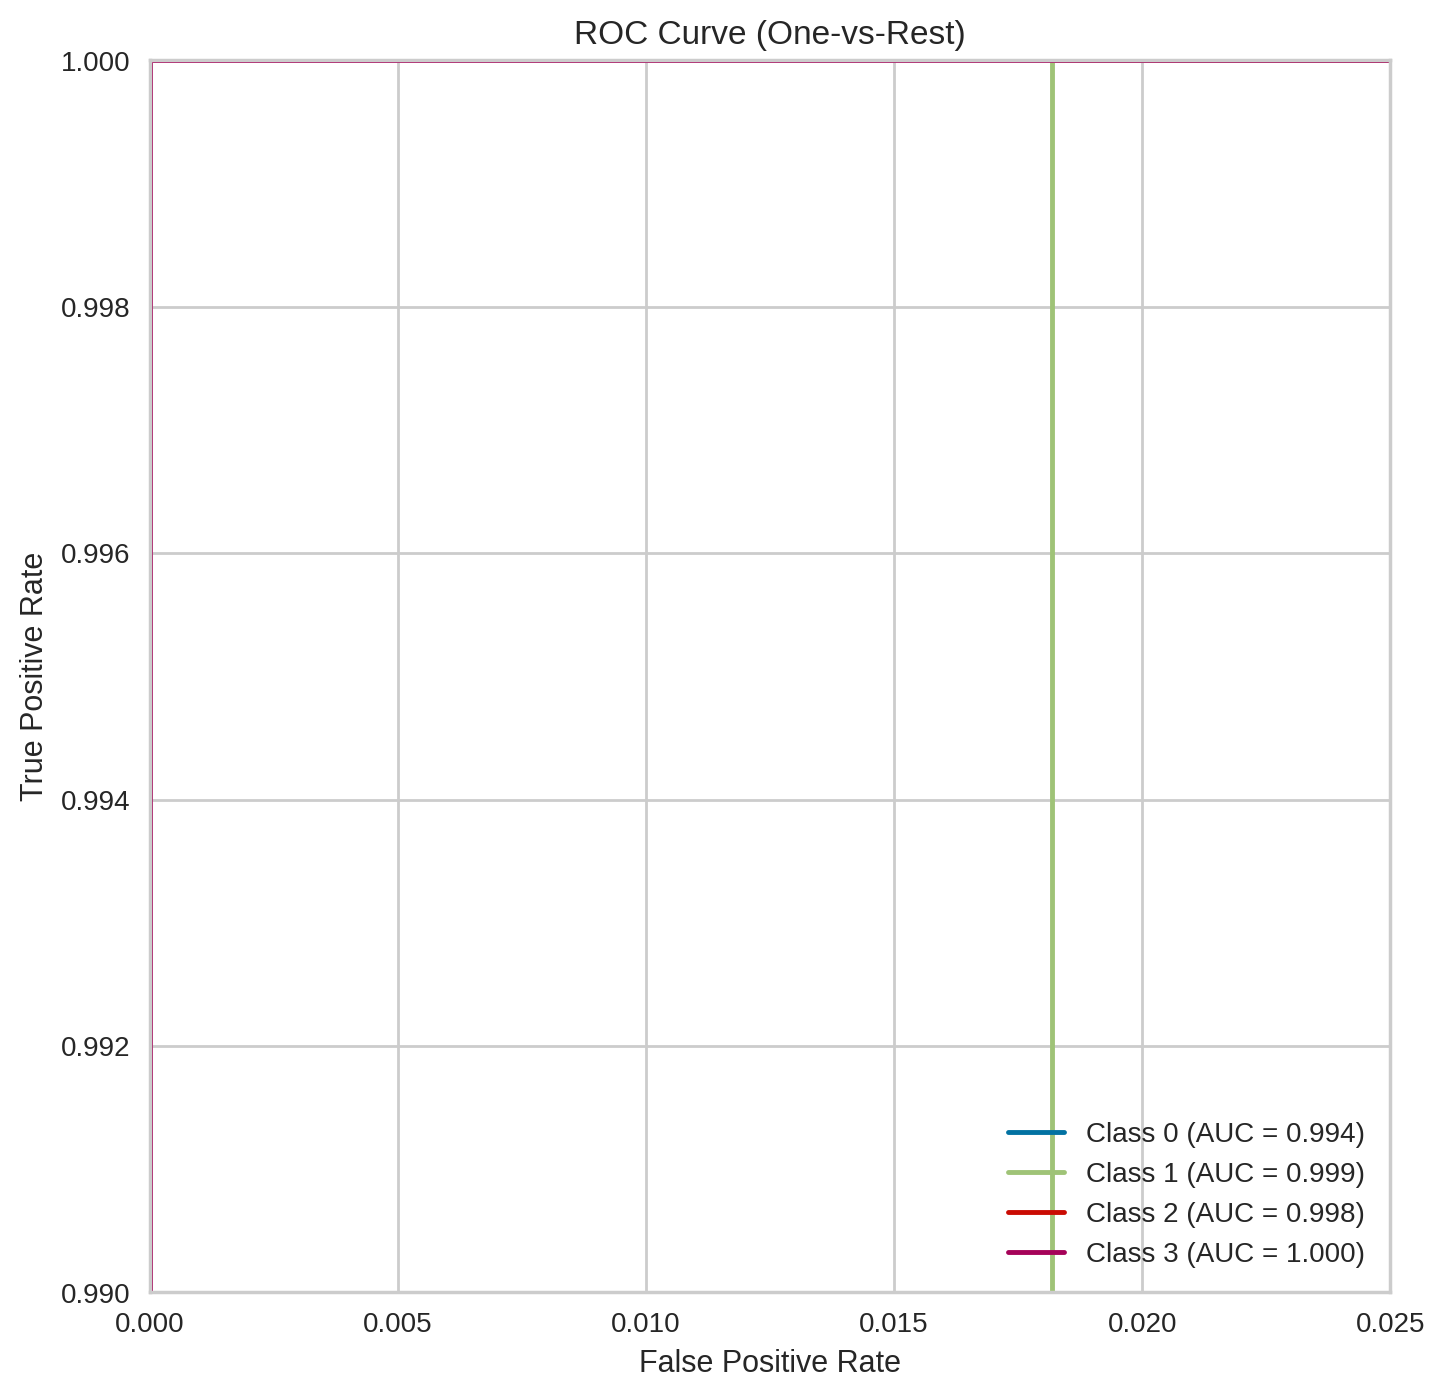

In [128]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()